# Malware Detection with SGD
LSTM classifier trained with Stochastic Gradient Descent on opcode sequences.

In [3]:
%pip install torch torchvision numpy pandas matplotlib scikit-learn python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Config

In [ ]:
MAX_SEQ_LEN           = 400
VOCAB_SIZE            = 600
BATCH_SIZE            = 64
NUM_EPOCHS            = 120
LR                    = 0.001
MIN_SAMPLES_PER_CLASS = 25

USE_IMAGES = False
USE_RR     = False
IMG_SIZE   = 64

opt  = 'rr'  if USE_RR     else 'sgd'
feat = 'img' if USE_IMAGES else 'seq'
mode = f'{opt}_{feat}'  # e.g. sgd_seq, sgd_img, rr_seq, rr_img


## Data Pipeline
Loads from cache (`input/X.pt`, `input/y.pt`, `input/meta.json`) if it exists -> takes ~15 seconds.
On first run reads the zip, filters rare families, encodes sequences, and saves the cache - slow but only happens once.

In [6]:
import zipfile, json as _json, os
import numpy as np

CACHE_X     = 'input/X.pt'
CACHE_Y     = 'input/y.pt'
CACHE_META  = 'input/meta.json'
CACHE_X_IMG = 'input/X_img.pt'

if USE_IMAGES:
    if not os.path.exists(CACHE_X_IMG):
        raise FileNotFoundError('Image cache not found. Run: python opcode_to_image.py')
    X = torch.load(CACHE_X_IMG)   # (N, 1, IMG_SIZE, IMG_SIZE)
    y = torch.load(CACHE_Y)
    with open(CACHE_META) as f:
        meta = _json.load(f)
    num_classes = meta['num_classes']
    label_map   = meta['label_map']
    vocab_size  = meta['vocab_size']
    print(f'Image mode - {X.shape[0]:,} samples, {num_classes} classes, shape {tuple(X.shape[1:])}')

elif os.path.exists(CACHE_X) and os.path.exists(CACHE_Y) and os.path.exists(CACHE_META):
    X = torch.load(CACHE_X)
    y = torch.load(CACHE_Y)
    with open(CACHE_META) as f:
        meta = _json.load(f)
    vocab_size  = meta['vocab_size']
    num_classes = meta['num_classes']
    label_map   = meta['label_map']
    print(f'Loaded from cache - {X.shape[0]:,} samples, {num_classes} classes')

else:
    print('Cache not found - processing from zip (one-time)...')
    rows, label_map = [], {}
    with zipfile.ZipFile('input/opcodes.zip') as z:
        entries = [e for e in z.infolist()
                   if not e.filename.endswith('/') and e.file_size > 0
                   and len(e.filename.split('/')) >= 3]
        print(f'  Reading {len(entries):,} files from zip...')
        for i, entry in enumerate(entries):
            parts  = entry.filename.split('/')
            family = parts[1]
            if family not in label_map:
                label_map[family] = len(label_map)
            raw = z.read(entry.filename).decode('utf-8', errors='replace')
            rows.append({'opcodes': ' '.join(raw.split()), 'label': label_map[family]})
            if (i + 1) % 25000 == 0:
                print(f'    {i+1:,} / {len(entries):,} files read...')
    df = pd.DataFrame(rows)
    print(f'  Read {len(df):,} samples, {df["label"].nunique()} families')
    counts        = df['label'].value_counts()
    keep          = counts[counts >= MIN_SAMPLES_PER_CLASS].index
    df            = df[df['label'].isin(keep)].copy()
    unique_labels = sorted(df['label'].unique())
    remap         = {old: new for new, old in enumerate(unique_labels)}
    df['label']   = df['label'].map(remap)
    label_map     = {fam: remap[idx] for fam, idx in label_map.items() if idx in remap}
    print(f'  After filtering: {len(df):,} samples, {df["label"].nunique()} classes')
    token_counts = Counter()
    for seq in df['opcodes']:
        token_counts.update(seq.split())
    most_common = [tok for tok, _ in token_counts.most_common(VOCAB_SIZE - 2)]
    token2idx   = {tok: i + 2 for i, tok in enumerate(most_common)}
    vocab_size  = len(token2idx) + 2
    print(f'  Vocab built - {vocab_size} tokens')
    opcodes_list = df['opcodes'].tolist()
    n    = len(opcodes_list)
    X_np = np.zeros((n, MAX_SEQ_LEN), dtype=np.int32)
    for i, seq in enumerate(opcodes_list):
        tokens = seq.split()[:MAX_SEQ_LEN]
        for j, t in enumerate(tokens):
            X_np[i, j] = token2idx.get(t, 1)
        if (i + 1) % 25000 == 0:
            print(f'    {i+1:,} / {n:,} encoded...')
    X           = torch.from_numpy(X_np).long()
    y           = torch.tensor(df['label'].values, dtype=torch.long)
    num_classes = int(y.unique().size(0))
    torch.save(X, CACHE_X)
    torch.save(y, CACHE_Y)
    with open(CACHE_META, 'w') as f:
        _json.dump({'vocab_size': vocab_size, 'num_classes': num_classes,
                    'label_map': label_map}, f)
    print('  Cache saved - future runs will load in ~15 seconds')


Image mode - 212,864 samples, 484 classes, shape (1, 64, 64)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

val_loader  = DataLoader(TensorDataset(X_val,  y_val),  batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

# SGD iterates over a shuffled DataLoader (shuffle handled by PyTorch internally)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle = not USE_RR)

Train: 153261  Val: 17030  Test: 42573


## Model
Embedding - LSTM - Linear.

In [8]:
# ---- BiLSTM + Attention (sequence mode) --------------------------------
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_out):
        scores  = self.attn(lstm_out)
        weights = torch.softmax(scores, dim=1)
        return (lstm_out * weights).sum(dim=1)


class MalwareLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 128, padding_idx=0)
        self.lstm      = nn.LSTM(128, 256, num_layers=2, batch_first=True,
                                 dropout=0.4, bidirectional=True)
        self.attention = Attention(256)
        self.dropout   = nn.Dropout(0.4)
        self.fc        = nn.Linear(256 * 2, num_classes)

    def forward(self, x):
        x       = self.embedding(x)
        out, _  = self.lstm(x)
        context = self.attention(out)
        return self.fc(self.dropout(context))


# ---- CNN (image mode) ---------------------------------------------------
class MalwareCNN(nn.Module):
    """4-block CNN for opcode images."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # block 1
            nn.Conv2d(1,  32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            # block 2
            nn.Conv2d(32, 64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            # block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            # block 4
            nn.Conv2d(128,256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        flat = 256 * (IMG_SIZE // 16) * (IMG_SIZE // 16)
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(flat, 512), nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))


model = (MalwareCNN() if USE_IMAGES else MalwareLSTM()).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')


MalwareCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

## Optimizer and Loss

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, eta_min=1e-5)


## Training Loop

In [10]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    # ---- train ----
    
    if (USE_RR):
        perm = torch.randperm(len(X_train))
        X_train_rr = X_train[perm]
        y_train_rr = y_train[perm]
        train_loader = DataLoader(TensorDataset(X_train_rr, y_train_rr), batch_size=BATCH_SIZE, shuffle=False)

    model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct    += (out.argmax(1) == yb).sum().item()
        total      += yb.size(0)

    train_loss = total_loss / total
    train_acc  = correct / total
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)

    # ---- validate ----
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            val_loss    += criterion(out, yb).item() * xb.size(0)
            val_correct += (out.argmax(1) == yb).sum().item()
            val_total   += yb.size(0)

    v_loss = val_loss / val_total
    v_acc  = val_correct / val_total
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:>2} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2%} | "
              f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.2%} | "
              f"LR: {lr_now:.5f}")

elapsed = time.time() - start_time
print(f"Training took {elapsed//3600:.0f}h {(elapsed%3600)//60:.0f}m {elapsed%60:.0f}s")

Epoch  1 | Train Loss: 3.8207  Acc: 40.27% | Val Loss: 3.2884  Acc: 48.26% | LR: 0.00099
Epoch  5 | Train Loss: 2.6920  Acc: 59.61% | Val Loss: 2.5930  Acc: 60.36% | LR: 0.00086
Epoch 10 | Train Loss: 2.2272  Acc: 68.18% | Val Loss: 2.3162  Acc: 67.60% | LR: 0.00051
Epoch 15 | Train Loss: 1.9152  Acc: 74.73% | Val Loss: 2.1072  Acc: 71.05% | LR: 0.00015
Epoch 20 | Train Loss: 1.7631  Acc: 78.48% | Val Loss: 2.0025  Acc: 73.41% | LR: 0.00100
Epoch 25 | Train Loss: 2.1100  Acc: 70.28% | Val Loss: 2.4831  Acc: 65.60% | LR: 0.00086
Epoch 30 | Train Loss: 1.9091  Acc: 74.75% | Val Loss: 2.2922  Acc: 68.33% | LR: 0.00051
Epoch 35 | Train Loss: 1.6837  Acc: 80.47% | Val Loss: 1.9562  Acc: 74.77% | LR: 0.00015
Epoch 40 | Train Loss: 1.5606  Acc: 83.76% | Val Loss: 1.9415  Acc: 75.45% | LR: 0.00100
Epoch 45 | Train Loss: 1.9885  Acc: 72.89% | Val Loss: 2.2944  Acc: 66.70% | LR: 0.00086
Epoch 50 | Train Loss: 1.8134  Acc: 77.10% | Val Loss: 2.0671  Acc: 71.63% | LR: 0.00051
Epoch 55 | Train Loss

## Training Curves

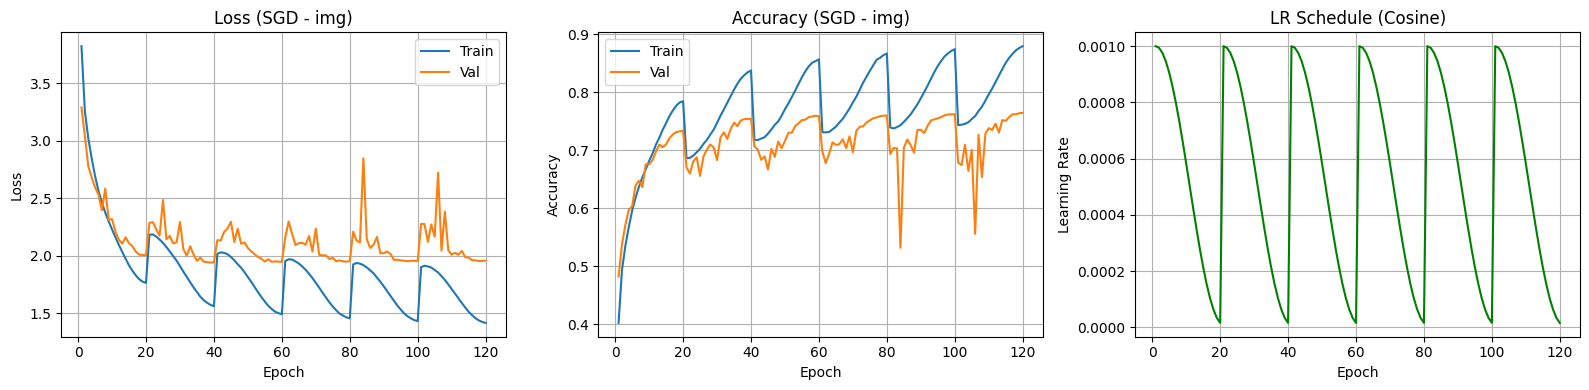

In [11]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['val_loss'],   label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title(f'Loss ({mode})'); ax1.legend(); ax1.grid(True)

ax2.plot(epochs, history['train_acc'], label='Train')
ax2.plot(epochs, history['val_acc'],   label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title(f'Accuracy ({mode})'); ax2.legend(); ax2.grid(True)

ax3.plot(epochs, history['lr'], color='green')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Learning Rate')
ax3.set_title('LR Schedule (Cosine)'); ax3.grid(True)

plt.tight_layout()
plt.savefig(f'output/{mode}_curves.png', dpi=150)
plt.show()


## Test Evaluation

In [12]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.96      0.72      0.82        32
           2       1.00      0.44      0.62        18
           3       0.82      0.70      0.75       233
           4       0.00      0.00      0.00         4
           5       1.00      0.29      0.45        31
           6       1.00      0.95      0.97        39
           7       1.00      0.79      0.88        75
           8       0.85      1.00      0.92        99
           9       0.28      0.41      0.33       562
          10       0.00      0.00      0.00         6
          11       0.86      0.62      0.72       129
          12       1.00      0.88      0.93         8
          13       0.50      0.50      0.50         2
          14       0.33      0.10      0.15        10
          15       0.97      0.93      0.95        30
          16       0.90      0.76      0.83       160
          17       1.00    

c:\Users\harun\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\harun\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\harun\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

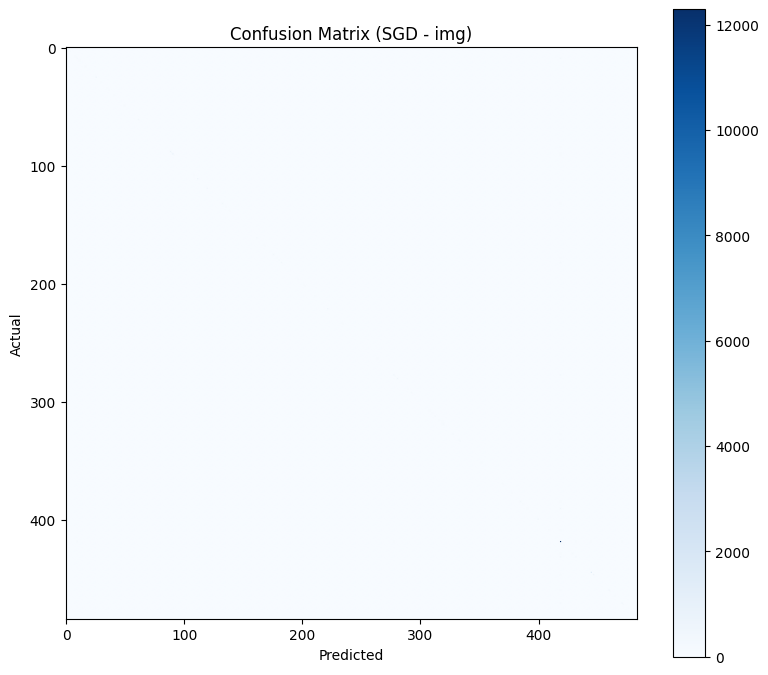

In [13]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix ({mode})')
plt.tight_layout()
plt.savefig(f'output/{mode}_confusion.png', dpi=150)
plt.show()


## Save

In [14]:
import json, os

os.makedirs('output', exist_ok=True)

with open(f'output/{mode}_history.json', 'w') as f:
    json.dump(history, f)

torch.save(model.state_dict(), f'output/{mode}_model.pt')

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f'Test accuracy: {test_acc:.2%}')
print(f'Saved to output/{mode}_*')


Test accuracy: 76.14%
Saved to output/sgd_img_*
